In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def show_image(image, title=None):
    """Display an image using matplotlib."""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

1. Erosion y dilatacion basicas: Aplicar erosion y dilatacion sobre una imagen binaria. Usar diferentes
tamaños de kernel. Comparar la imagen original y la resultante de aplicar el operador. Comentar
los efectos visuales.

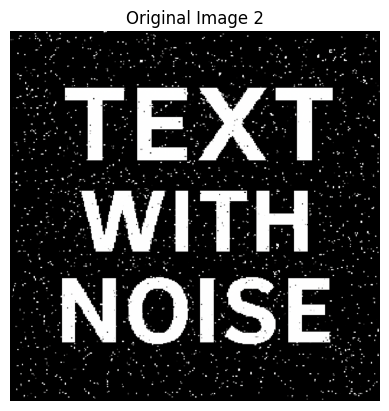

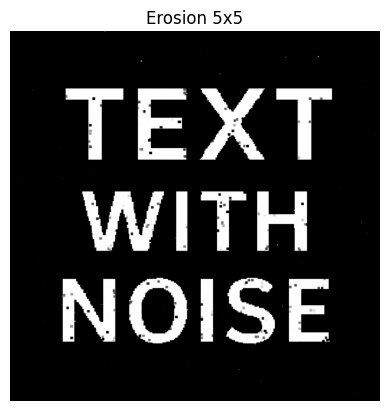

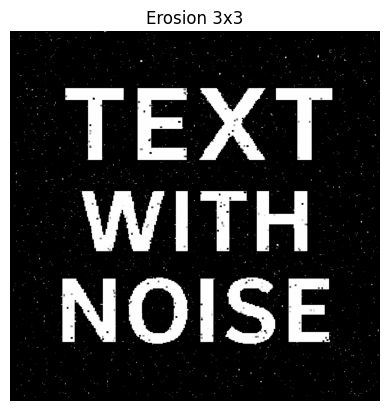

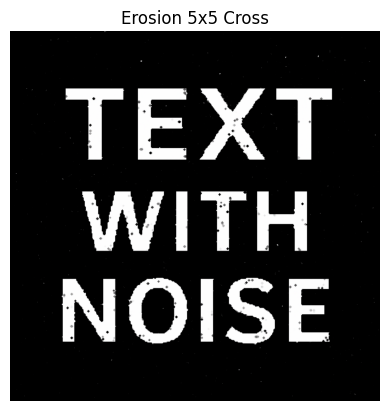

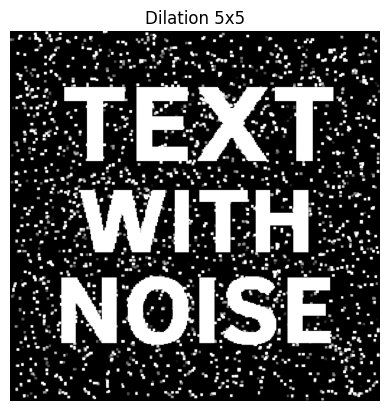

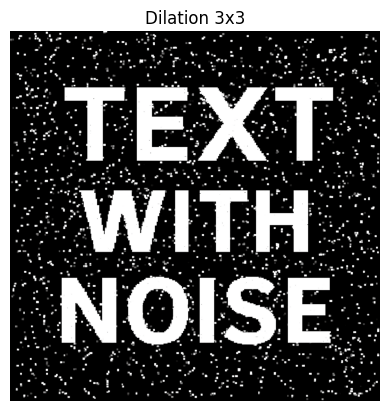

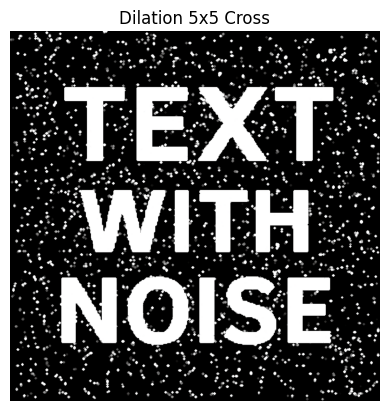

In [7]:
img1 = cv2.imread('bin1.png')
img2 = cv2.imread('bin2.png')
img3 = cv2.imread('bin3.png')

img_chosen = 2

kernel5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
kernel3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
kernel5_2 = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))

# Erosion
erosion1_5 = cv2.erode(img1, kernel5)
erosion1_3 = cv2.erode(img1, kernel3)
erosion1_5_2 = cv2.erode(img1, kernel5_2)
erosion2_5 = cv2.erode(img2, kernel5)
erosion2_3 = cv2.erode(img2, kernel3)
erosion2_5_2 = cv2.erode(img2, kernel5_2)
erosion3_5 = cv2.erode(img3, kernel5)
erosion3_3 = cv2.erode(img3, kernel3)
erosion3_5_2 = cv2.erode(img3, kernel5_2)
# Dilatacion
dilation1_5 = cv2.dilate(img1, kernel5)
dilation1_3 = cv2.dilate(img1, kernel3)
dilation1_5_2 = cv2.dilate(img1, kernel5_2)
dilation2_5 = cv2.dilate(img2, kernel5)
dilation2_3 = cv2.dilate(img2, kernel3)
dilation2_5_2 = cv2.dilate(img2, kernel5_2)
dilation3_5 = cv2.dilate(img3, kernel5)
dilation3_3 = cv2.dilate(img3, kernel3)
dilation3_5_2 = cv2.dilate(img3, kernel5_2)
# Print
if img_chosen == 1:    
    show_image(img1, 'Original Image 1')
    show_image(erosion1_5, 'Erosion 5x5')
    show_image(erosion1_3, 'Erosion 3x3')
    show_image(erosion1_5_2, 'Erosion 5x5 Cross')
    show_image(dilation1_5, 'Dilation 5x5')
    show_image(dilation1_3, 'Dilation 3x3')
    show_image(dilation1_5_2, 'Dilation 5x5 Cross')
elif img_chosen == 2:
    show_image(img2, 'Original Image 2')
    show_image(erosion2_5, 'Erosion 5x5')
    show_image(erosion2_3, 'Erosion 3x3')
    show_image(erosion2_5_2, 'Erosion 5x5 Cross')
    show_image(dilation2_5, 'Dilation 5x5')
    show_image(dilation2_3, 'Dilation 3x3')
    show_image(dilation2_5_2, 'Dilation 5x5 Cross')
elif img_chosen == 3:
    show_image(img3, 'Original Image 3')
    show_image(erosion3_5, 'Erosion 5x5')
    show_image(erosion3_3, 'Erosion 3x3')
    show_image(erosion3_5_2, 'Erosion 5x5 Cross')
    show_image(dilation3_5, 'Dilation 5x5')
    show_image(dilation3_3, 'Dilation 3x3')
    show_image(dilation3_5_2, 'Dilation 5x5 Cross')






Cuando erosionamos la imagen, se tiende a eliminar el detalle fino como se puede ver en la imagen con ruido y los bordes tienden a expandirse.
Cuando dilatamos la imagen, se tiende a intensificar pequeños detalles y amplificar los bordes.

2. Erosion y dilatacion sobre bordes detectados: Aplicar erosion/dilatacion sobre una imagen de bordes
para ensanchar o suavizar lıneas.

3. Relleno de objetos usando clausura morfologica: Aplicar clausura morfologico para rellenar objetos
interrumpidos por ruido.

4. (*) Apertura y clausura morfologica: Aplicar apertura y clausura para eliminar ruido o cerrar huecos.
Comparar la imagen original y la resultante de aplicar el operador. Comentar los efectos visuales.
Comparar con los resultados anteriores. Mostrar 4 subplots: original, apertura, cierre, diferencia
entre ambos.


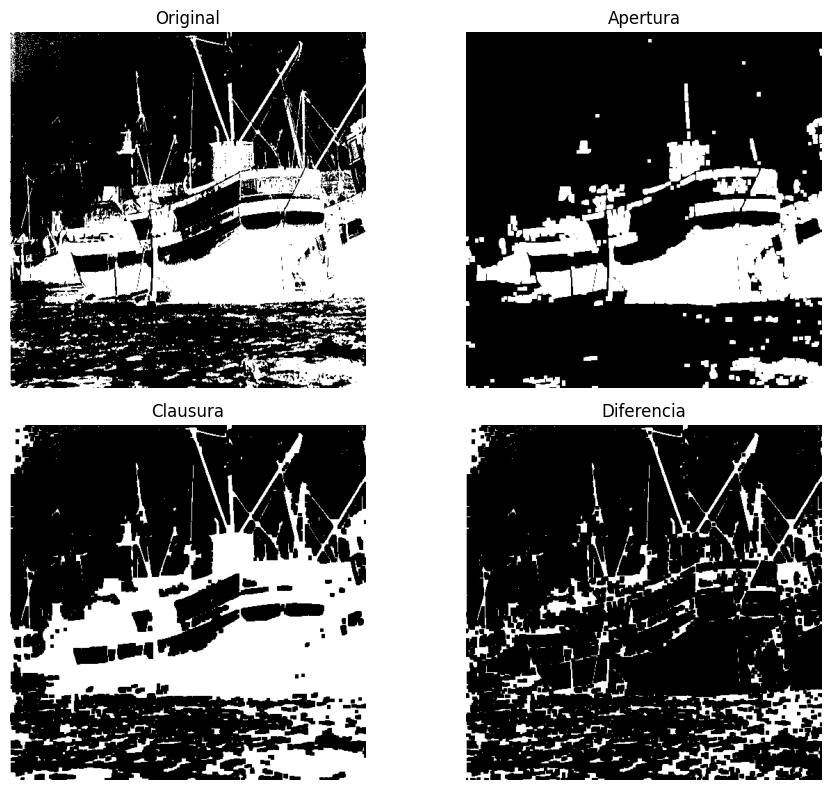

In [8]:
boat = cv2.imread('boat.png')
_, boat_bin = cv2.threshold(boat, 127, 255, cv2.THRESH_BINARY_INV)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
# Aplicamos apertura y cierre
apertura = cv2.morphologyEx(boat_bin, cv2.MORPH_OPEN, kernel)
clausura = cv2.morphologyEx(boat_bin, cv2.MORPH_CLOSE, kernel)
diferencia = cv2.absdiff(apertura, clausura)

def mostrar_img(titulo, imagen, pos):
    plt.subplot(2, 2, pos)
    plt.imshow(imagen, cmap='gray')
    plt.title(titulo)
    plt.axis('off')

plt.figure(figsize=(10, 8))
mostrar_img("Original", boat_bin, 1)
mostrar_img("Apertura", apertura, 2)
mostrar_img("Clausura", clausura, 3)
mostrar_img("Diferencia", diferencia, 4)
plt.tight_layout()
plt.show()

##### Apertura: Elimina el ruido y suviza los bordes
##### Clausura: Cierra los huecos y une los objetos separados

La diferencia entre aplicar operaciones como dilatacion o erosion es que la apertura y clausura permite tener terminaciones mas finas. Dicho de otra manera, si solo aplicaramos una erosion o dilatacion, ademas de eliminar cosas como el ruido o agrandar detalles, tambien se crea una pequeña deformacion de los objetos mas grandes. Si aplicamos una apertura o clausura podemos conseguir eliminar ruido, suavizar bordes o cerrar huecos (dependiendo que es lo que necesitemos hacer) sin perder tanto la forma de los objetos grandes.

5. (*) Operacion de gradiente morfologico: Aplicar el gradiente morfologico (dilatacion - erosion). Visualizar los bordes obtenidos mediante esta operacion.


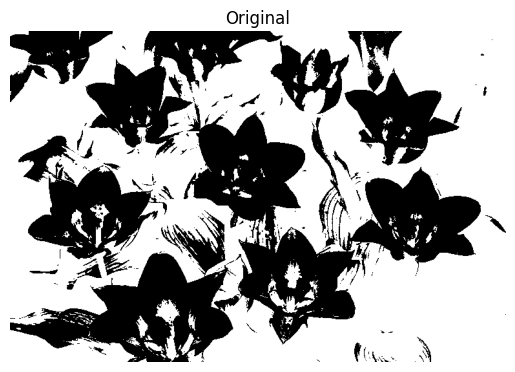

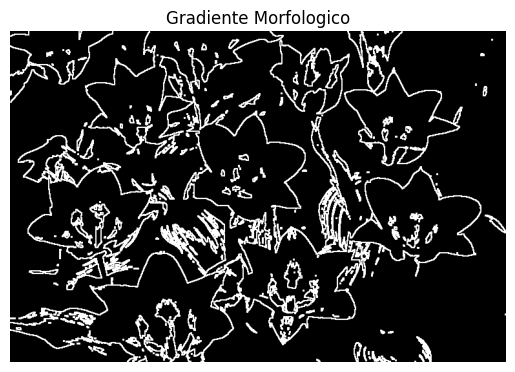

In [16]:
img = cv2.imread('tulips.png', cv2.IMREAD_GRAYSCALE)
_, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

dialatacion = cv2.dilate(img_bin, kernel)
erosion = cv2.erode(img_bin, kernel)

gradiente = cv2.subtract(dialatacion, erosion)

show_image(img_bin, 'Original')
show_image(gradiente, 'Gradiente Morfologico')

6. Deteccion de bordes con morfologıa: Generar una imagen de bordes usando diferencia entre la imagen
original y su erosion o dilatacion.


7. (*) Segmentacion basica con umbral + morfologıa: Aplicar umbral, luego apertura y cierre para
mejorar el resultado. Ideal como paso previo a una segmentacion mas elaborada.


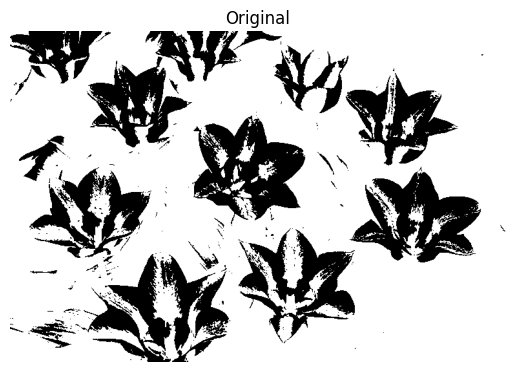

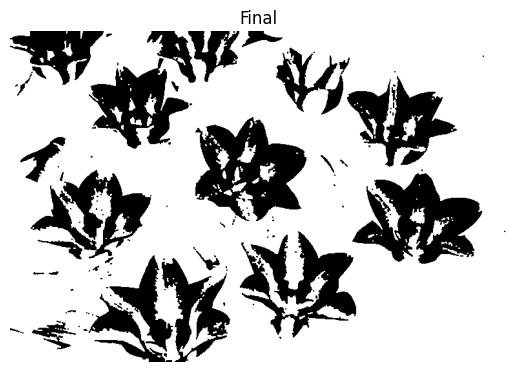

In [19]:
img = cv2.imread('tulips.png', cv2.IMREAD_GRAYSCALE)
_, img_bin = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY_INV)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
apertura = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)
clausura = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, kernel)

show_image(img_bin, 'Original')
show_image(clausura, 'Final')